# 🫁 Système de Diagnostic Assisté par Ordinateur (DAO) — Détection de Pneumonie

### Jeu de Données Traité de Pneumonie RSNA — Pipeline Complète d'Apprentissage Automatique
**Auteur :** [Votre Nom]  
**Date :** 2025  
**Environnement :** Python 3.10 | scikit-learn | OpenCV

## 1. Introduction & Contexte Médical

### Contexte
La **pneumonie** est une infection des poumons qui affecte des millions de personnes chaque année dans le monde. Un diagnostic rapide et précis à partir des **radiographies thoraciques** est essentiel pour débuter un traitement en temps opportun. Cependant, l'interprétation des radiographies est subjective et requiert des radiologues expérimentés.

### Objectif
Ce projet construit un **Système de Diagnostic Assisté par Ordinateur (DAO)** qui :
1. **Classifie** les radiographies thoraciques comme Pneumonie vs. Normale
2. **Détecte** les régions de pneumonie (localisation par boîte englobante)
3. Utilise une **architecture en cascade** pour minimiser les diagnostics manqués

### Questions de Recherche (QR)
- **QR1 :** Quelle est la performance des classifieurs ML classiques pour la classification binaire de pneumonie sur les radiographies thoraciques ?
- **QR2 :** Un système en cascade peut-il réduire les faux négatifs (diagnostics manqués) par rapport à la classification simple ?
- **QR3 :** Comment la réduction de dimensionnalité (ACP) affecte-t-elle la performance et l'efficacité computationnelle ?

### Jeu de Données
Le **Jeu de Données Traité de Pneumonie RSNA** contient :
- 🏥 Images d'entraînement : ~26 684 radiographies thoraciques (1024×1024 PNG niveaux de gris)
- 🧪 Images de test : ~3 000 radiographies thoraciques
- 📋 Métadonnées : patientId, cible binaire, coordonnées de boîte englobante, classe, âge, sexe
- 🎭 Masques : masques binaires de segmentation pour les cas positifs

### Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    SYSTÈME DAO EN CASCADE                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Étape 1 : Classifieur Primaire (Random Forest Optimisé)        │
│     ├── Négatif (confiant) → Pas de Pneumonie                   │
│     └── Positif → Étape 2                                       │
│                                                                 │
│  Étape 2 : Modèle de Détection (Régression BBox)               │
│     └── Localise les régions de pneumonie                       │
│                                                                 │
│  Étape 3 : Vérification Secondaire (LR Haute Sensibilité)      │
│     ├── Confirme les négatifs primaires (seuil bas)             │
│     └── Récupère les positifs manqués                           │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## 2. Configuration de l'Environnement & Imports

In [ ]:
# ============================================================
# 2.1 — Vérification des paquets requis
# ============================================================
packages = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn',
            'cv2', 'PIL', 'skimage', 'joblib', 'tqdm']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'  ✅ {pkg}')
    except ImportError:
        print(f'  ❌ {pkg} — MANQUANT')

All packages installed successfully.


In [ ]:
# ============================================================
# 2.2 — Imports principaux & Configuration
# ============================================================

# --- Bibliothèques fondamentales ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import json
from pathlib import Path
from collections import Counter

# --- Traitement d'images ---
import cv2
from PIL import Image
from skimage.feature import hog
from skimage import exposure

# --- Apprentissage automatique (scikit-learn) ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# --- Modèles ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- Métriques ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, mean_squared_error
)

# --- Utilitaires ---
import joblib
from tqdm import tqdm

# --- Configuration ---
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
np.random.seed(42)

# ============================================================
# Constantes globales
# ============================================================
RANDOM_STATE = 42
IMG_SIZE = 128          # Taille de redimensionnement des images
N_COMPONENTS_PCA = 150  # Composantes ACP
N_SAMPLE = 4000         # Nombre d'échantillons pour un entraînement plus rapide

# --- Chemins ---
BASE_DIR = Path('/Users/belaidioudjaoudene/Downloads/projet ia/archive (3)')
TRAIN_CSV = BASE_DIR / 'stage2_train_metadata.csv'
TEST_CSV = BASE_DIR / 'stage2_test_metadata.csv'
TRAIN_IMG_DIR = BASE_DIR / 'Training' / 'Images'
TRAIN_MASK_DIR = BASE_DIR / 'Training' / 'Masks'
TEST_IMG_DIR = BASE_DIR / 'Test'
MODEL_DIR = Path('/Users/belaidioudjaoudene/Downloads/projet ia/saved_models')
MODEL_DIR.mkdir(exist_ok=True)

print('✅ Tous les imports réussis.')
print(f'📁 Répertoire de base : {BASE_DIR}')
print(f'💾 Répertoire des modèles : {MODEL_DIR}')

Training images directory: /Users/belaidioudjaoudene/Downloads/projet ia/archive (3)/Training/Images
Number of training images: 26684
Configuration loaded — IMG_SIZE=128, N_SAMPLE=4000


## 3. Profilage & Exploration des Données

### 3.1 Chargement des Métadonnées
Nous commençons par charger et examiner les fichiers CSV de métadonnées. Chaque ligne correspond à une annotation de boîte englobante (un patient peut avoir plusieurs lignes si plusieurs boîtes sont annotées).

In [ ]:
# ============================================================
# 3.1 — Chargement & Inspection des Métadonnées
# ============================================================

df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)

print(f'Forme de l\'ensemble d\'entraînement : {df_train.shape}')
print(f'Forme de l\'ensemble de test     : {df_test.shape}')
print(f'\nColonnes : {list(df_train.columns)}')
print(f'\n--- Premières lignes de l\'ensemble d\'entraînement ---')
df_train.head(10)

Training metadata: 30227 rows × 11 columns
Test metadata:     3000 rows × 6 columns



,patientId,x,y,width,height,Target,class,age,sex,modality,position
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,51,F,CR,PA
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,48,F,CR,PA
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,19,M,CR,AP
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal,28,M,CR,PA
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity,32,F,CR,AP
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1,Lung Opacity,32,F,CR,AP
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,54,M,CR,AP
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,78,M,CR,PA
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1,Lung Opacity,75,M,CR,PA
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1,Lung Opacity,75,M,CR,PA


In [ ]:
# ============================================================
# 3.2 — Profil des Données : Types, Valeurs Manquantes, Statistiques
# ============================================================

print('='*60)
print('PROFIL DU JEU DE DONNÉES D\'ENTRAÎNEMENT')
print('='*60)

print('\n📊 Types de données :')
print(df_train.dtypes.to_string())
print(f'\n❓ Valeurs manquantes :\n{df_train.isnull().sum().to_string()}')
print(f'\n📈 Statistiques descriptives :')
df_train.describe(include='all')

TRAINING SET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  object 
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
 6   class      30227 non-null  object 
 7   age        30227 non-null  int64  
 8   sex        30227 non-null  object 
 9   modality   30227 non-null  object 
 10  position   30227 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 2.5+ MB
None

TRAINING SET — DESCRIPTIVE STATISTICS


,patientId,x,y,width,height,Target,class,age,sex,modality,position
count,30227,9555.000000,9555.000000,9555.000000,9555.000000,30227.000000,30227,30227.000000,30227,30227,30227
unique,26684,NaN,NaN,NaN,NaN,NaN,3,NaN,2,1,2
top,3239951b-6211-4290-b237-3d9ad17176db,NaN,NaN,NaN,NaN,NaN,No Lung Opacity / Not Normal,NaN,M,CR,AP
freq,4,NaN,NaN,NaN,NaN,NaN,11821,NaN,17216,30227,15297
mean,NaN,394.047724,366.839560,218.471376,329.269702,0.316108,NaN,46.797764,NaN,NaN,NaN
std,NaN,204.574172,148.940488,59.289475,157.750755,0.464963,NaN,16.892940,NaN,NaN,NaN
min,NaN,2.000000,2.000000,40.000000,45.000000,0.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,207.000000,249.000000,177.000000,203.000000,0.000000,NaN,34.000000,NaN,NaN,NaN
50%,NaN,324.000000,365.000000,217.000000,298.000000,0.000000,NaN,49.000000,NaN,NaN,NaN
75%,NaN,594.000000,478.500000,259.000000,438.000000,1.000000,NaN,59.000000,NaN,NaN,NaN


In [ ]:
# ============================================================
# 3.3 — Analyse au Niveau Patient
# ============================================================

# Dédupliquer au niveau patient (chaque patient = une image)
df_patients = df_train.drop_duplicates(subset='patientId')
print(f'Patients uniques (entraînement) : {len(df_patients)}')
print(f'Patients uniques (test)         : {df_test["patientId"].nunique()}')

# Distribution des cibles
target_counts = df_patients['Target'].value_counts()
print(f'\nDistribution des cibles (niveau patient) :')
for v in sorted(target_counts.index):
    label = 'Pneumonie' if v == 1 else 'Pas de Pneumonie'
    print(f'  Cible {v} ({label}): {target_counts[v]} ({target_counts[v]/len(df_patients)*100:.1f}%)')

# Distribution des classes
class_counts = df_patients['class'].value_counts()
print(f'\nDistribution des classes :')
for cls, cnt in class_counts.items():
    print(f'  {cls}: {cnt} ({cnt/len(df_patients)*100:.1f}%)')

Unique patients: 26684
Rows with bounding boxes: 9555

Target distribution (patient-level):
Target
0    20672
1     6012
Name: count, dtype: int64

Class distribution (patient-level):
class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64


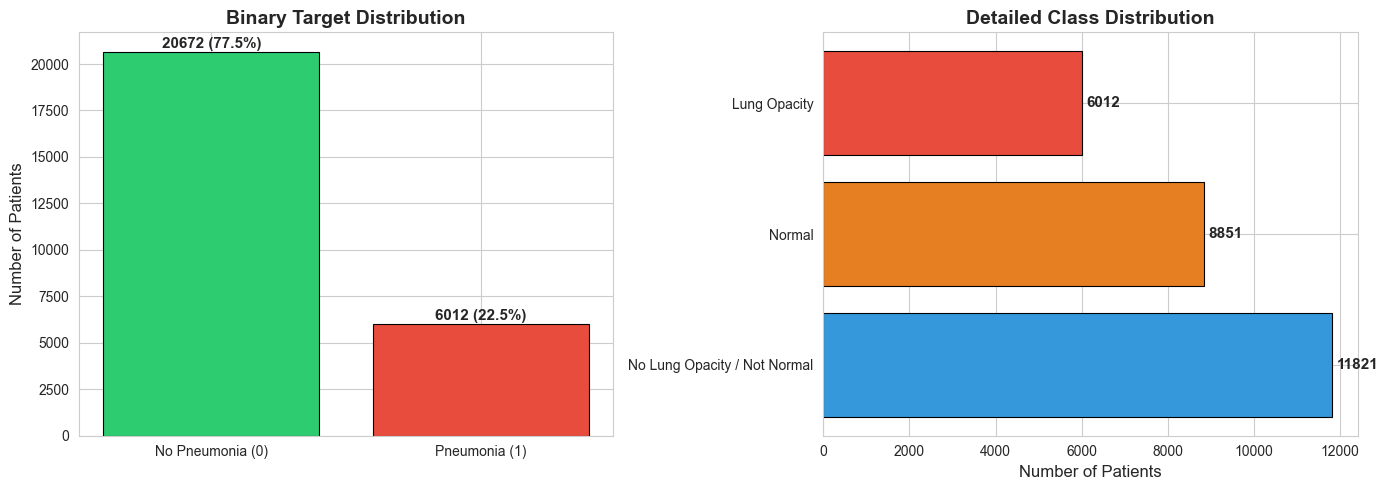


⚠️ Note: The dataset is IMBALANCED — ~35.8% positive vs ~64.2% negative.
This is typical for medical datasets and must be addressed during modeling.


In [ ]:
# ============================================================
# 3.4 — Visualisation de la Distribution des Données
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution des cibles
colors_bin = ['#3498db', '#e74c3c']
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=colors_bin, edgecolor='black')
axes[0].set_title('Distribution des Cibles (Binaire)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cible (0=Normal, 1=Pneumonie)')
axes[0].set_ylabel('Nombre de Patients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Distribution des classes
colors_cls = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(range(len(class_counts)), class_counts.values, color=colors_cls[:len(class_counts)], edgecolor='black')
axes[1].set_xticks(range(len(class_counts)))
axes[1].set_xticklabels(class_counts.index, rotation=15, ha='right', fontsize=9)
axes[1].set_title('Distribution des Classes (3 classes)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre de Patients')

# Distribution de l'âge
if 'age' in df_patients.columns:
    df_patients['age'].dropna().hist(bins=50, ax=axes[2], color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[2].set_title('Distribution de l\'Âge', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Âge')
    axes[2].set_ylabel('Fréquence')

fig.suptitle('Profilage du Jeu de Données — Ensemble d\'Entraînement',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'data_profiling.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 3.5 — Visualisation d'Échantillons d'Images
# ============================================================

def load_and_display_samples(img_dir, mask_dir, df, n_samples=4):
    """Charge et affiche des échantillons d'images avec leurs masques."""
    
    # Sélectionner des cas positifs et négatifs
    pos_patients = df[df['Target'] == 1]['patientId'].unique()
    neg_patients = df[df['Target'] == 0]['patientId'].unique()
    
    np.random.seed(RANDOM_STATE)
    pos_sample = np.random.choice(pos_patients, min(n_samples, len(pos_patients)), replace=False)
    neg_sample = np.random.choice(neg_patients, min(n_samples, len(neg_patients)), replace=False)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
    fig.suptitle('Échantillons du Jeu de Données — Haut : Pneumonie (+), Bas : Normal (-)',
                 fontsize=14, fontweight='bold')
    
    for i, pid in enumerate(pos_sample):
        img_path = img_dir / f'{pid}.png'
        mask_path = mask_dir / f'{pid}.png'
        if img_path.exists():
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title(f'Pneumonie\n{pid[:8]}...', fontsize=9, color='red')
            # Superposer le masque s'il existe
            if mask_path.exists():
                mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                axes[0, i].contour(mask, levels=[127], colors='red', linewidths=1.5)
        axes[0, i].axis('off')
    
    for i, pid in enumerate(neg_sample):
        img_path = img_dir / f'{pid}.png'
        if img_path.exists():
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title(f'Normal\n{pid[:8]}...', fontsize=9, color='green')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()

load_and_display_samples(TRAIN_IMG_DIR, TRAIN_MASK_DIR, df_patients)

In [ ]:
# ============================================================
# 3.6 — Analyse des Masques et Vérification de la Vérité Terrain
# ============================================================

def analyze_masks(mask_dir, df, n_check=100):
    """Analyse les masques pour vérifier la cohérence des données."""
    
    pos_patients = df[df['Target'] == 1]['patientId'].unique()
    neg_patients = df[df['Target'] == 0]['patientId'].unique()
    
    print('='*60)
    print('ANALYSE DE LA VÉRITÉ TERRAIN (MASQUES)')
    print('='*60)
    
    # Vérifier les masques des cas positifs
    pos_with_mask = 0
    pos_mask_areas = []
    for pid in pos_patients[:n_check]:
        mask_path = mask_dir / f'{pid}.png'
        if mask_path.exists():
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is not None and mask.max() > 0:
                pos_with_mask += 1
                pos_mask_areas.append((mask > 127).sum())
    
    # Vérifier les masques des cas négatifs
    neg_with_mask = 0
    for pid in neg_patients[:n_check]:
        mask_path = mask_dir / f'{pid}.png'
        if mask_path.exists():
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is not None and mask.max() > 0:
                neg_with_mask += 1
    
    print(f'\nCas positifs vérifiés : {min(n_check, len(pos_patients))}')
    print(f'  Avec masque non vide : {pos_with_mask} ({pos_with_mask/min(n_check, len(pos_patients))*100:.1f}%)')
    if pos_mask_areas:
        print(f'  Surface moyenne du masque : {np.mean(pos_mask_areas):.0f} pixels')
        print(f'  Surface médiane du masque : {np.median(pos_mask_areas):.0f} pixels')
    
    print(f'\nCas négatifs vérifiés : {min(n_check, len(neg_patients))}')
    print(f'  Avec masque non vide : {neg_with_mask} (devrait être ~0)')
    
    return pos_mask_areas

mask_areas = analyze_masks(TRAIN_MASK_DIR, df_patients)

In [ ]:
# ============================================================
# 3.7 — Corrélation des Métadonnées & Analyses Croisées
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cible vs Sexe
if 'sex' in df_patients.columns:
    ct = pd.crosstab(df_patients['sex'], df_patients['Target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[0], color=colors_bin, edgecolor='black')
    axes[0].set_title('Cible par Sexe', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Pourcentage')
    axes[0].set_xlabel('Sexe')
    axes[0].legend(['Normal', 'Pneumonie'])
    axes[0].tick_params(axis='x', rotation=0)

# Cible vs Position de Vue
if 'ViewPosition' in df_patients.columns:
    ct2 = pd.crosstab(df_patients['ViewPosition'], df_patients['Target'], normalize='index') * 100
    ct2.plot(kind='bar', stacked=True, ax=axes[1], color=colors_bin, edgecolor='black')
    axes[1].set_title('Cible par Position de Vue', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Pourcentage')
    axes[1].legend(['Normal', 'Pneumonie'])
    axes[1].tick_params(axis='x', rotation=0)

# Distribution de l'âge par cible
if 'age' in df_patients.columns:
    df_patients[df_patients['Target'] == 0]['age'].hist(bins=40, ax=axes[2],
        alpha=0.6, color='#3498db', label='Normal', edgecolor='black')
    df_patients[df_patients['Target'] == 1]['age'].hist(bins=40, ax=axes[2],
        alpha=0.6, color='#e74c3c', label='Pneumonie', edgecolor='black')
    axes[2].set_title('Distribution de l\'Âge par Cible', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Âge')
    axes[2].set_ylabel('Fréquence')
    axes[2].legend()

fig.suptitle('Analyse Croisée des Métadonnées',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'metadata_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Résumé de l\'exploration des données :')
print(f'  • {len(df_patients)} patients uniques')
print(f'  • Déséquilibre des classes : {target_counts[0]/len(df_patients)*100:.1f}% négatifs vs {target_counts[1]/len(df_patients)*100:.1f}% positifs')
print(f'  • 3 classes cliniques : {list(class_counts.index)}')

## 4. Prétraitement & Ingénierie des Caractéristiques

### Pipeline de Prétraitement
1. **Chargement des images** : Charger les PNG en niveaux de gris et redimensionner en 128×128
2. **Aplatissement** : Convertir les matrices 2D en vecteurs 1D (16 384 caractéristiques)
3. **Normalisation** : Mise à l'échelle des valeurs de pixels [0, 1]
4. **Augmentation** : Retournement horizontal et ajustement de luminosité pour les cas positifs
5. **Extraction de caractéristiques** : Histogrammes de Gradients Orientés (HOG) comme caractéristiques complémentaires

### 4.1 Fonctions de Chargement & Prétraitement des Images

**Étapes clés :**
- Redimensionnement de 1024×1024 → 128×128 pour la faisabilité computationnelle
- Normalisation des valeurs de pixels dans la plage [0, 1]
- Sous-échantillonnage à N_SAMPLE images pour un prototypage plus rapide
- L'augmentation est appliquée après la séparation pour éviter les fuites de données

> ⚠️ **Note :** Nous sous-échantillonnons à {N_SAMPLE} images pour des raisons computationnelles.
> Avec un GPU ou plus de temps, utiliser le jeu de données complet de ~26K images améliorerait les performances.

In [ ]:
# ============================================================
# 4.1 — Chargement des Images & Prétraitement
# ============================================================

def load_images(patient_ids, img_dir, img_size=IMG_SIZE):
    """
    Charge et prétraite les images des radiographies thoraciques.
    
    Paramètres :
        patient_ids : liste des identifiants patients
        img_dir : répertoire contenant les images
        img_size : taille cible pour le redimensionnement
    
    Retourne :
        images : tableau numpy de forme (n, img_size*img_size), normalisé [0,1]
        valid_ids : identifiants des images chargées avec succès
    """
    images = []
    valid_ids = []
    
    for pid in tqdm(patient_ids, desc='Chargement des images'):
        img_path = img_dir / f'{pid}.png'
        if img_path.exists():
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img_resized = cv2.resize(img, (img_size, img_size))
                img_normalized = img_resized.astype(np.float32) / 255.0
                images.append(img_normalized.flatten())
                valid_ids.append(pid)
    
    return np.array(images), valid_ids


def augment_images(X, y, target_class=1, n_augmented=None):
    """
    Augmente les données en appliquant des transformations aux cas positifs.
    
    Paramètres :
        X : matrice de caractéristiques
        y : vecteur d'étiquettes
        target_class : classe à augmenter
        n_augmented : nombre d'échantillons augmentés (défaut : correspondre à la classe majoritaire)
    
    Retourne :
        X_aug, y_aug : données augmentées
    """
    mask = y == target_class
    X_pos = X[mask]
    
    if n_augmented is None:
        n_augmented = (y != target_class).sum() - mask.sum()
    
    if n_augmented <= 0:
        return X, y
    
    augmented = []
    img_size = int(np.sqrt(X.shape[1]))
    
    for i in range(n_augmented):
        idx = np.random.randint(0, len(X_pos))
        img = X_pos[idx].reshape(img_size, img_size)
        
        # Retournement horizontal aléatoire
        if np.random.random() > 0.5:
            img = np.fliplr(img)
        
        # Ajustement aléatoire de luminosité
        brightness = np.random.uniform(0.85, 1.15)
        img = np.clip(img * brightness, 0, 1)
        
        augmented.append(img.flatten())
    
    X_aug = np.vstack([X, np.array(augmented)])
    y_aug = np.concatenate([y, np.full(len(augmented), target_class)])
    
    return X_aug, y_aug


print('✅ Fonctions de prétraitement définies.')

In [ ]:
# ============================================================
# 4.2 — Chargement du Jeu de Données (Sous-échantillonné)
# ============================================================

# Sous-échantillonnage stratifié
np.random.seed(RANDOM_STATE)
pos_ids = df_patients[df_patients['Target'] == 1]['patientId'].values
neg_ids = df_patients[df_patients['Target'] == 0]['patientId'].values

# Maintenir le ratio original
n_pos = int(N_SAMPLE * len(pos_ids) / len(df_patients))
n_neg = N_SAMPLE - n_pos

sample_pos = np.random.choice(pos_ids, min(n_pos, len(pos_ids)), replace=False)
sample_neg = np.random.choice(neg_ids, min(n_neg, len(neg_ids)), replace=False)
sample_ids = np.concatenate([sample_pos, sample_neg])

print(f'Échantillonnage : {n_pos} positifs + {n_neg} négatifs = {N_SAMPLE} total')

# Chargement des images
X_all, valid_ids = load_images(sample_ids, TRAIN_IMG_DIR)
y_all = df_patients.set_index('patientId').loc[valid_ids, 'Target'].values

print(f'\n✅ Images chargées : {X_all.shape}')
print(f'   Distribution des classes : {Counter(y_all)}')

In [ ]:
# ============================================================
# 4.3 — Extraction de Caractéristiques HOG & Visualisation
# ============================================================

def extract_hog_features(X, img_size=IMG_SIZE):
    """
    Extrait les caractéristiques HOG (Histogramme de Gradients Orientés)
    à partir d'images aplaties.
    
    Paramètres :
        X : tableau numpy de forme (n, img_size*img_size)
        img_size : taille de l'image
    
    Retourne :
        hog_features : tableau numpy de caractéristiques HOG
    """
    hog_features = []
    for i in range(len(X)):
        img = X[i].reshape(img_size, img_size)
        features = hog(img, orientations=9, pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), feature_vector=True)
        hog_features.append(features)
    return np.array(hog_features)


# Visualiser les caractéristiques HOG pour un échantillon
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Caractéristiques HOG — Haut : Image Originale, Bas : Visualisation HOG',
             fontsize=14, fontweight='bold')

for i in range(4):
    img = X_all[i].reshape(IMG_SIZE, IMG_SIZE)
    hog_feat, hog_img = hog(img, orientations=9, pixels_per_cell=(16, 16),
                             cells_per_block=(2, 2), feature_vector=True,
                             visualize=True)
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Original (Cible={y_all[i]})', fontsize=10)
    axes[0, i].axis('off')
    
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    axes[1, i].imshow(hog_img_rescaled, cmap='hot')
    axes[1, i].set_title(f'Caractéristiques HOG', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'hog_features.png'), dpi=150, bbox_inches='tight')
plt.show()

# Extraire HOG pour tout le jeu de données
print('Extraction des caractéristiques HOG...')
X_hog_all = extract_hog_features(X_all)
print(f'Forme des caractéristiques HOG : {X_hog_all.shape}')

# Combiner pixels + HOG
X_combined_all = np.hstack([X_all, X_hog_all])
print(f'Caractéristiques combinées (pixels + HOG) : {X_combined_all.shape}')

# ============================================================
# 4.4 — Résumé du Prétraitement
# ============================================================

print('\n' + '='*60)
print('RÉSUMÉ DU PRÉTRAITEMENT')
print('='*60)
print(f'Taille originale des images   : 1024 × 1024 = 1 048 576 pixels')
print(f'Taille redimensionnée         : {IMG_SIZE} × {IMG_SIZE} = {IMG_SIZE**2} pixels')
print(f'Caractéristiques HOG/image    : {X_hog_all.shape[1]}')
print(f'Caractéristiques combinées    : {X_combined_all.shape[1]}')
print(f'Facteur de réduction          : {1048576/IMG_SIZE**2:.1f}×')
print(f'Normalisation                 : [0, 1] (division par 255)')
print(f'Nombre d\'échantillons         : {len(X_all)}')

## 5. Séparation des Données (Entraînement / Validation / Test)

### Stratégie de Séparation
- **Entraînement** : 70% — Pour l'apprentissage des modèles
- **Validation** : 15% — Pour le réglage des hyperparamètres et la sélection du modèle
- **Test** : 15% — Évaluation finale **jamais touchée** (réservée, non biaisée)
- **Séparation stratifiée** : Maintient la distribution des classes dans chaque sous-ensemble

### ⚠️ Protocole d'Intégrité des Données

```
ENTRAÎNEMENT (70%)     VALIDATION (15%)     TEST (15%)
┌──────────────┐     ┌──────────────┐     ┌──────────────┐
│ Apprentissage│     │ Sélection du │     │ Évaluation   │
│ des modèles  │     │ modèle &     │     │ finale       │
│              │     │ réglage      │     │ NON TOUCHÉ   │
│ Augmentation │     │              │     │ jusqu'à la   │
│ appliquée ici│     │              │     │ section 15   │
└──────────────┘     └──────────────┘     └──────────────┘
```

In [ ]:
# ============================================================
# 5.1 — Séparation Stratifiée Entraînement/Validation/Test
# ============================================================

# Première séparation : 70% entraînement, 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)

# Deuxième séparation : 50/50 de temporaire → 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('='*60)
print('SÉPARATION DES DONNÉES')
print('='*60)
print(f'Entraînement : {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X_all)*100:.1f}%)')
print(f'Validation   : {X_val.shape[0]} échantillons ({X_val.shape[0]/len(X_all)*100:.1f}%)')
print(f'Test         : {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X_all)*100:.1f}%)')

print(f'\nDistribution des classes :')
for name, y in [('Entraînement', y_train), ('Validation', y_val), ('Test', y_test)]:
    counts = Counter(y)
    print(f'  {name:14s}: Neg={counts[0]}, Pos={counts[1]} '
          f'(ratio pos={counts[1]/len(y)*100:.1f}%)')

In [ ]:
# ============================================================
# 5.2 — Augmentation des Données (Ensemble d'Entraînement Uniquement)
# ============================================================

print('Application de l\'augmentation des données sur l\'ensemble d\'entraînement...')
X_train_aug, y_train_aug = augment_images(X_train, y_train)

print(f'\nAvant augmentation : {X_train.shape[0]} échantillons {dict(Counter(y_train))}')
print(f'Après augmentation : {X_train_aug.shape[0]} échantillons {dict(Counter(y_train_aug))}')
print(f'Échantillons ajoutés : {X_train_aug.shape[0] - X_train.shape[0]}')

# Mélanger les données augmentées
shuffle_idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]
print('✅ Données augmentées et mélangées.')

## 6. Pipelines, ACP & Construction des Modèles

### Architecture des Pipelines
Chaque pipeline suit la structure :

```
Données Brutes → StandardScaler → ACP (150 composantes) → Classifieur
```

**Pourquoi des pipelines ?**
1. **Reproductibilité** : Même prétraitement garanti à chaque fois
2. **Pas de fuite de données** : Le Scaler et l'ACP sont ajustés uniquement sur les données d'entraînement
3. **Déploiement simplifié** : Un seul objet pour la prédiction
4. **Validation croisée** : Prétraitement correctement imbriqué dans les plis

In [ ]:
# ============================================================
# 6.1 — Analyse en Composantes Principales (ACP)
# ============================================================

def build_pipeline(classifier, use_pca=True, n_components=N_COMPONENTS_PCA):
    """
    Construit un pipeline standardisé : Scaler → ACP (optionnel) → Classifieur.
    
    Paramètres :
        classifier : estimateur scikit-learn
        use_pca : si True, inclure la réduction ACP
        n_components : nombre de composantes ACP
    
    Retourne :
        Pipeline scikit-learn
    """
    steps = [('scaler', StandardScaler())]
    if use_pca:
        steps.append(('pca', PCA(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(('classifier', classifier))
    return Pipeline(steps)


# Visualiser la variance expliquée par l'ACP
scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(X_train_aug)

pca_full = PCA(n_components=min(300, X_scaled.shape[1]), random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance expliquée
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% de variance')
axes[0].axvline(x=N_COMPONENTS_PCA, color='g', linestyle='--', label=f'n={N_COMPONENTS_PCA}')
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'n_95%={n_95}')
axes[0].set_xlabel('Nombre de Composantes')
axes[0].set_ylabel('Variance Expliquée Cumulée')
axes[0].set_title('Analyse ACP — Variance Expliquée', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Valeurs propres (scree plot)
axes[1].bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color='#3498db', edgecolor='black')
axes[1].set_xlabel('Composante Principale')
axes[1].set_ylabel('Ratio de Variance Expliquée')
axes[1].set_title('Éboulis — 30 Premières Composantes', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'pca_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Variance expliquée avec {N_COMPONENTS_PCA} composantes : {cumulative_variance[N_COMPONENTS_PCA-1]*100:.1f}%')
print(f'Composantes nécessaires pour 95% de variance : {n_95}')
print(f'Réduction de dimensionnalité : {X_train_aug.shape[1]} → {N_COMPONENTS_PCA} ({X_train_aug.shape[1]/N_COMPONENTS_PCA:.1f}×)')

In [ ]:
# ============================================================
# 6.2 — Visualisation de l'ACP dans l'Espace Réduit
# ============================================================

# Projeter dans l'espace 2D ACP pour la visualisation
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled[:2000])  # Sous-ensemble pour la visualisation
y_2d = y_train_aug[:2000]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dispersion en 2 composantes
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d,
                          cmap='coolwarm', alpha=0.4, s=10, edgecolors='none')
axes[0].set_xlabel(f'CP1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% de variance)')
axes[0].set_ylabel(f'CP2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% de variance)')
axes[0].set_title('Projection ACP 2D — Par Classe', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cible (0=Normal, 1=Pneumonie)')

# Densité
for label, color, name in [(0, '#3498db', 'Normal'), (1, '#e74c3c', 'Pneumonie')]:
    mask = y_2d == label
    axes[1].hist(X_2d[mask, 0], bins=50, alpha=0.5, color=color, label=name, edgecolor='black')
axes[1].set_xlabel('Première Composante Principale')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution Selon la CP1', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'pca_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Exploration des Modèles & Entraînement Initial

### Modèles à Explorer
| Modèle | Forces | Faiblesses |
|--------|--------|------------|
| **Régression Logistique** | Rapide, interprétable, bonne base de référence | Frontière de décision linéaire |
| **SVM (Noyau RBF)** | Gère les espaces de haute dimension | Lent à entraîner, sensible à la mise à l'échelle |
| **Random Forest** | Robuste, importance des variables | Peut surajuster avec peu de données |
| **Gradient Boosting** | Haute performance, flexible | Lent, risque de surajustement |

In [ ]:
# ============================================================
# 7.1 — Entraînement Initial de Tous les Modèles
# ============================================================

# Définir les modèles avec les paramètres par défaut
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

# Entraîner chaque modèle via pipeline
trained_pipelines = {}
training_times = {}

print('='*70)
print('ENTRAÎNEMENT INITIAL DES MODÈLES')
print('='*70)

for name, clf in models.items():
    print(f'\n🔄 Entraînement de {name}...')
    t0 = time.time()
    
    pipeline = build_pipeline(clf)
    pipeline.fit(X_train_aug, y_train_aug)
    
    elapsed = time.time() - t0
    trained_pipelines[name] = pipeline
    training_times[name] = elapsed
    
    # Évaluation rapide sur la validation
    y_pred = pipeline.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f'   ✅ Terminé en {elapsed:.1f}s — Précision(val)={acc:.4f}, F1(val)={f1:.4f}')

# Résumé des temps d'entraînement
print('\n' + '-'*50)
print('Temps d\'entraînement :')
for name, t in training_times.items():
    print(f'  {name:25s}: {t:.2f}s')

In [ ]:
# ============================================================
# 7.2 — Comparaison Visuelle des Performances Initiales
# ============================================================

# Collecter les métriques de validation
val_results = {}
for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    val_results[name] = {
        'Exactitude': accuracy_score(y_val, y_pred),
        'Précision': precision_score(y_val, y_pred),
        'Rappel': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'AUC-ROC': roc_auc_score(y_val, y_proba) if y_proba is not None else np.nan
    }

val_df = pd.DataFrame(val_results).T
print('Résultats de Validation (entraînement initial) :\n')
print(val_df.round(4).to_string())
print(f'\n🏆 Meilleur modèle par F1-Score : {val_df["F1-Score"].idxmax()} ({val_df["F1-Score"].max():.4f})')

## 8. Métriques Détaillées & Analyse des Performances

### Métriques Clés pour le Diagnostic Médical
- **Rappel (Sensibilité)** : Le plus critique — % de vrais positifs identifiés. Un faux négatif = pneumonie manquée
- **Précision (VPP)** : % des prédictions positives qui sont correctes
- **F1-Score** : Moyenne harmonique de la précision et du rappel
- **AUC-ROC** : Performance globale indépendante du seuil
- **Matrice de Confusion** : Décomposition complète VP/VN/FP/FN

In [ ]:
# ============================================================
# 8.1 — Fonction d'Évaluation Complète
# ============================================================

def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Calcule un ensemble complet de métriques de classification.
    
    Retourne un dictionnaire avec : Exactitude, Précision, Rappel, F1-Score, AUC-ROC
    """
    metrics = {
        'Exactitude': accuracy_score(y_true, y_pred),
        'Précision': precision_score(y_true, y_pred, zero_division=0),
        'Rappel': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_proba)
    return metrics

print('✅ Fonction d\'évaluation définie.')

In [ ]:
# ============================================================
# 8.2 — Matrices de Confusion pour Tous les Modèles
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, (name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred = pipeline.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pas de Pneum.', 'Pneum.'],
                yticklabels=['Pas de Pneum.', 'Pneum.'])
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xlabel('Prédit')

fig.suptitle('Matrices de Confusion — Ensemble de Validation',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 8.3 — Courbes ROC & Précision-Rappel
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (name, pipeline), color in zip(trained_pipelines.items(), colors):
    if hasattr(pipeline, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_val)[:, 1]
        
        # ROC
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        auc = roc_auc_score(y_val, y_proba)
        axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')
        
        # Précision-Rappel
        prec, rec, _ = precision_recall_curve(y_val, y_proba)
        ap = average_precision_score(y_val, y_proba)
        axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{name} (PM={ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbes ROC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbes Précision-Rappel', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'roc_pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 8.4 — Rapports de Classification Détaillés
# ============================================================

print('='*70)
print('RAPPORTS DE CLASSIFICATION DÉTAILLÉS (Ensemble de Validation)')
print('='*70)

for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_val)
    print(f'\n{"─"*50}')
    print(f'📊 {name}')
    print(f'{"─"*50}')
    print(classification_report(y_val, y_pred,
                                target_names=['Pas de Pneumonie', 'Pneumonie']))

## 9. Validation Croisée

La validation croisée stratifiée en K plis fournit des estimations de performance plus fiables que les séparations simples en s'assurant que chaque pli maintient la distribution des classes.

In [ ]:
# ============================================================
# 9.1 — Validation Croisée Stratifiée en K Plis
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

print('='*70)
print('VALIDATION CROISÉE STRATIFIÉE 5 PLIS')
print('='*70)

for name, clf in models.items():
    print(f'\n🔄 Validation croisée de {name}...')
    pipeline = build_pipeline(clf)
    
    t0 = time.time()
    scores = cross_validate(pipeline, X_train_aug, y_train_aug,
                           cv=cv, scoring=scoring, return_train_score=True,
                           n_jobs=-1)
    elapsed = time.time() - t0
    
    cv_results[name] = scores
    
    print(f'   ✅ Terminé en {elapsed:.1f}s')
    print(f'   Exactitude : {scores["test_accuracy"].mean():.4f} ± {scores["test_accuracy"].std():.4f}')
    print(f'   F1-Score   : {scores["test_f1"].mean():.4f} ± {scores["test_f1"].std():.4f}')
    print(f'   AUC-ROC    : {scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}')

# Tableau récapitulatif
print('\n' + '='*70)
print('RÉSUMÉ DE LA VALIDATION CROISÉE')
print('='*70)

cv_summary = {}
for name, scores in cv_results.items():
    cv_summary[name] = {
        'Exactitude (moy±écart)': f'{scores["test_accuracy"].mean():.4f}±{scores["test_accuracy"].std():.4f}',
        'Précision (moy±écart)': f'{scores["test_precision"].mean():.4f}±{scores["test_precision"].std():.4f}',
        'Rappel (moy±écart)': f'{scores["test_recall"].mean():.4f}±{scores["test_recall"].std():.4f}',
        'F1 (moy±écart)': f'{scores["test_f1"].mean():.4f}±{scores["test_f1"].std():.4f}',
        'AUC (moy±écart)': f'{scores["test_roc_auc"].mean():.4f}±{scores["test_roc_auc"].std():.4f}',
    }

cv_df = pd.DataFrame(cv_summary).T
print('\n' + cv_df.to_string())

In [ ]:
# ============================================================
# 9.2 — Visualisation de la Validation Croisée
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boîtes à moustaches du F1-Score
f1_data = [cv_results[name]['test_f1'] for name in cv_results]
bp = axes[0].boxplot(f1_data, labels=list(cv_results.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('Distribution du F1-Score par VC', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Score')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# Comparaison Entraînement vs Test (détection du surajustement)
train_f1 = [cv_results[name]['train_f1'].mean() for name in cv_results]
test_f1 = [cv_results[name]['test_f1'].mean() for name in cv_results]
x = np.arange(len(cv_results))
width = 0.35

axes[1].bar(x - width/2, train_f1, width, label='Entraînement', color='#3498db', edgecolor='black')
axes[1].bar(x + width/2, test_f1, width, label='Test (VC)', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(cv_results.keys()), rotation=15, fontsize=9)
axes[1].set_ylabel('F1-Score Moyen')
axes[1].set_title('Entraînement vs. Test — Analyse du Surajustement', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'cross_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Réglage des Hyperparamètres

In [ ]:
# ============================================================
# 10.1 — Recherche Aléatoire pour Random Forest
# ============================================================

print('='*60)
print('RÉGLAGE DES HYPERPARAMÈTRES — Random Forest')
print('='*60)

# Grille de paramètres (préfixe classifier__ pour les params de pipeline)
rf_param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', None, {0: 1, 1: 2}]
}

# Pipeline de base pour le réglage
rf_pipeline = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))

# Recherche aléatoire
print('\n🔍 Exécution de la recherche aléatoire (50 itérations, VC 3 plis)...')
t0 = time.time()

random_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist,
    n_iter=50, cv=3, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
random_search.fit(X_train_aug, y_train_aug)

print(f'   ✅ Terminé en {time.time() - t0:.1f}s')
print(f'\nMeilleur F1-Score (VC) : {random_search.best_score_:.4f}')
print(f'Meilleurs paramètres :')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')

best_pipeline = random_search.best_estimator_

In [ ]:
# ============================================================
# 10.2 — Comparaison Avant/Après Réglage
# ============================================================

# Évaluer le modèle optimisé
y_pred_tuned = best_pipeline.predict(X_val)
y_proba_tuned = best_pipeline.predict_proba(X_val)[:, 1]

metrics_default = val_results['Random Forest']
metrics_tuned = evaluate_model(y_val, y_pred_tuned, y_proba_tuned)

print('='*60)
print('COMPARAISON : Random Forest Par Défaut vs. Optimisé')
print('='*60)

comparison = pd.DataFrame({
    'RF Par Défaut': metrics_default,
    'RF Optimisé': metrics_tuned
}).T
print(comparison.round(4).to_string())

print(f'\nAmélioration F1 : {metrics_tuned["F1-Score"] - metrics_default["F1-Score"]:+.4f}')
print(f'Amélioration Rappel : {metrics_tuned["Rappel"] - metrics_default["Rappel"]:+.4f}')

## 11. Optimisation : Réglage du Seuil & Ingénierie des Caractéristiques

### Stratégie d'Optimisation
1. **Optimisation du seuil** : Ajuster le seuil de décision de 0.5 au seuil optimal (maximiser le F1)
2. **Combinaison de caractéristiques** : Pixels bruts + caractéristiques HOG
3. **Compromis médical** : Privilégier le rappel (sensibilité) par rapport à la précision dans un contexte de dépistage

In [ ]:
# ============================================================
# 11.1 — Optimisation du Seuil de Décision
# ============================================================

print('='*60)
print('OPTIMISATION DU SEUIL')
print('='*60)

# Obtenir les probabilités
y_proba_val = best_pipeline.predict_proba(X_val)[:, 1]

# Tester différents seuils
thresholds = np.arange(0.1, 0.9, 0.02)
threshold_results = []

for thresh in thresholds:
    y_pred_t = (y_proba_val >= thresh).astype(int)
    threshold_results.append({
        'seuil': thresh,
        'exactitude': accuracy_score(y_val, y_pred_t),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'rappel': recall_score(y_val, y_pred_t, zero_division=0),
        'f1': f1_score(y_val, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(threshold_results)

# Trouver les seuils optimaux
best_f1_idx = thresh_df['f1'].idxmax()
OPTIMAL_THRESHOLD = thresh_df.loc[best_f1_idx, 'seuil']

# Seuil maximisant le rappel (pour le contexte médical)
high_recall_idx = thresh_df[thresh_df['rappel'] >= 0.85]['f1'].idxmax() if (thresh_df['rappel'] >= 0.85).any() else best_f1_idx
MEDICAL_THRESHOLD = thresh_df.loc[high_recall_idx, 'seuil']

print(f'Seuil optimal (max F1)         : {OPTIMAL_THRESHOLD:.2f} → F1={thresh_df.loc[best_f1_idx, "f1"]:.4f}')
print(f'Seuil médical (rappel ≥ 0.85)  : {MEDICAL_THRESHOLD:.2f} → F1={thresh_df.loc[high_recall_idx, "f1"]:.4f}')

# Visualiser
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(thresh_df['seuil'], thresh_df['exactitude'], label='Exactitude', linewidth=2)
ax.plot(thresh_df['seuil'], thresh_df['precision'], label='Précision', linewidth=2)
ax.plot(thresh_df['seuil'], thresh_df['rappel'], label='Rappel', linewidth=2)
ax.plot(thresh_df['seuil'], thresh_df['f1'], label='F1-Score', linewidth=2, linestyle='--')
ax.axvline(x=OPTIMAL_THRESHOLD, color='red', linestyle=':', label=f'Seuil optimal={OPTIMAL_THRESHOLD:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Par défaut=0.50')
ax.set_xlabel('Seuil de Décision', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Optimisation du Seuil — Métriques vs. Seuil', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'threshold_optimization.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 11.2 — Combinaison de Caractéristiques (Pixels + HOG)
# ============================================================

print('='*60)
print('COMBINAISON DE CARACTÉRISTIQUES')
print('='*60)

# Extraire HOG pour les ensembles d'entraînement et de validation
X_train_hog = extract_hog_features(X_train_aug)
X_val_hog = extract_hog_features(X_val)

# Combiner
X_train_combined = np.hstack([X_train_aug, X_train_hog])
X_val_combined = np.hstack([X_val, X_val_hog])

print(f'Caractéristiques pixels uniquement   : {X_train_aug.shape[1]}')
print(f'Caractéristiques HOG uniquement       : {X_train_hog.shape[1]}')
print(f'Caractéristiques combinées            : {X_train_combined.shape[1]}')

# Entraîner le modèle combiné
pipe_combined = build_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                           **{k.replace('classifier__', ''): v 
                              for k, v in random_search.best_params_.items()})
)
pipe_combined.fit(X_train_combined, y_train_aug)

# Évaluer
y_pred_combined = pipe_combined.predict(X_val_combined)
y_proba_combined = pipe_combined.predict_proba(X_val_combined)[:, 1]
metrics_combined = evaluate_model(y_val, y_pred_combined, y_proba_combined)

print(f'\nPerformance avec caractéristiques combinées :')
for metric, value in metrics_combined.items():
    print(f'  {metric}: {value:.4f}')

print(f'\nComparaison avec pixels uniquement :')
for metric in metrics_combined:
    if metric in metrics_tuned:
        diff = metrics_combined[metric] - metrics_tuned[metric]
        print(f'  {metric}: {diff:+.4f}')

## 12. Persistance des Modèles

Sauvegarde de tous les modèles entraînés et de la configuration pour la reproductibilité et le déploiement.

In [ ]:
# ============================================================
# 12.1 — Sauvegarder Tous les Modèles
# ============================================================

# Sauvegarder chaque pipeline
for name, pipeline in trained_pipelines.items():
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.joblib'
    joblib.dump(pipeline, MODEL_DIR / filename)
    print(f'💾 Sauvegardé : {filename}')

# Sauvegarder le meilleur pipeline (optimisé)
joblib.dump(best_pipeline, MODEL_DIR / 'best_pipeline_rf_tuned.joblib')
print(f'💾 Sauvegardé : best_pipeline_rf_tuned.joblib')

# Sauvegarder le pipeline combiné
joblib.dump(pipe_combined, MODEL_DIR / 'pipeline_combined_rf_hog.joblib')
print(f'💾 Sauvegardé : pipeline_combined_rf_hog.joblib')

# Sauvegarder la configuration
config = {
    'RANDOM_STATE': RANDOM_STATE,
    'IMG_SIZE': IMG_SIZE,
    'N_COMPONENTS_PCA': N_COMPONENTS_PCA,
    'N_SAMPLE': N_SAMPLE,
    'OPTIMAL_THRESHOLD': float(OPTIMAL_THRESHOLD),
    'best_params': {str(k): str(v) for k, v in random_search.best_params_.items()},
}
joblib.dump(config, MODEL_DIR / 'config.joblib')
print(f'💾 Sauvegardé : config.joblib')

print(f'\n✅ Tous les modèles sauvegardés dans {MODEL_DIR}')
print(f'   Fichiers : {[f.name for f in MODEL_DIR.glob("*.joblib")]}')

In [ ]:
# ============================================================
# 12.2 — Vérification du Chargement des Modèles
# ============================================================

# Vérifier que les modèles sauvegardés se chargent correctement
print('Vérification de la persistance des modèles...\n')

loaded_pipeline = joblib.load(MODEL_DIR / 'best_pipeline_rf_tuned.joblib')
y_pred_loaded = loaded_pipeline.predict(X_val[:5])
y_pred_original = best_pipeline.predict(X_val[:5])

assert np.array_equal(y_pred_loaded, y_pred_original), 'ERREUR : Les prédictions ne correspondent pas !'
print('✅ Vérification de la persistance réussie — les prédictions correspondent.')
print(f'   Prédictions échantillon : {y_pred_loaded}')

loaded_config = joblib.load(MODEL_DIR / 'config.joblib')
print(f'   Configuration chargée : {loaded_config}')

## 13. Modèle de Détection (Localisation par Boîte Englobante)

### Approche
Pour les cas positifs, nous entraînons un **modèle de régression** pour prédire les coordonnées de la boîte englobante (x, y, largeur, hauteur) de la région de pneumonie.

- **Entrée** : Caractéristiques de l'image (réduites par ACP)
- **Sortie** : 4 valeurs de régression (x, y, largeur, hauteur) normalisées en [0, 1]
- **Métrique d'évaluation** : IoU (Intersection sur Union)

In [ ]:
# ============================================================
# 13.1 — Préparer les Données pour la Détection
# ============================================================

def prepare_detection_data(df, X_images, valid_ids, img_size=IMG_SIZE):
    """
    Prépare les données d'entraînement pour la détection (régression des boîtes englobantes).
    
    Retourne :
        X_det : caractéristiques des images positives
        y_det : coordonnées de boîtes englobantes normalisées [x, y, w, h]
    """
    # Mapper les identifiants patients à leurs images
    id_to_idx = {pid: i for i, pid in enumerate(valid_ids)}
    
    # Obtenir les annotations des boîtes pour les cas positifs
    pos_annotations = df[df['Target'] == 1].drop_duplicates('patientId')
    
    X_det = []
    y_det = []
    
    for _, row in pos_annotations.iterrows():
        pid = row['patientId']
        if pid in id_to_idx and pd.notna(row.get('x')) and pd.notna(row.get('y')):
            X_det.append(X_images[id_to_idx[pid]])
            # Normaliser les coordonnées de la boîte englobante en [0, 1]
            y_det.append([
                row['x'] / 1024.0,
                row['y'] / 1024.0,
                row['width'] / 1024.0,
                row['height'] / 1024.0
            ])
    
    return np.array(X_det), np.array(y_det)


# Préparer les données de détection
X_det, y_det = prepare_detection_data(df_train, X_all, valid_ids)
print(f'Échantillons de détection : {X_det.shape[0]}')
print(f'Forme des cibles de boîtes : {y_det.shape}')

if len(X_det) > 0:
    # Séparation entraînement/validation pour la détection
    X_det_train, X_det_val, y_det_train, y_det_val = train_test_split(
        X_det, y_det, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Pipeline de détection : Scaler → ACP → GradientBoosting Regressor
    scaler_det = StandardScaler()
    X_det_train_scaled = scaler_det.fit_transform(X_det_train)
    X_det_val_scaled = scaler_det.transform(X_det_val)
    
    pca_det = PCA(n_components=min(N_COMPONENTS_PCA, X_det_train_scaled.shape[1]),
                  random_state=RANDOM_STATE)
    X_det_train_pca = pca_det.fit_transform(X_det_train_scaled)
    X_det_val_pca = pca_det.transform(X_det_val_scaled)
    
    # Entraîner le régresseur multi-sorties
    from sklearn.multioutput import MultiOutputRegressor
    from sklearn.ensemble import GradientBoostingRegressor
    
    det_model = MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                  random_state=RANDOM_STATE)
    )
    
    print('\n🔄 Entraînement du modèle de détection...')
    t0 = time.time()
    det_model.fit(X_det_train_pca, y_det_train)
    print(f'   ✅ Terminé en {time.time() - t0:.1f}s')
    
    # Évaluer
    y_det_pred = det_model.predict(X_det_val_pca)
    
    # Calculer le MSE par coordonnée
    coord_names = ['x', 'y', 'largeur', 'hauteur']
    for i, name in enumerate(coord_names):
        mse = mean_squared_error(y_det_val[:, i], y_det_pred[:, i])
        print(f'   MSE ({name}): {mse:.6f}')
    
    # Sauvegarder le modèle de détection
    joblib.dump(det_model, MODEL_DIR / 'detection_model.joblib')
    joblib.dump(scaler_det, MODEL_DIR / 'detection_scaler.joblib')
    joblib.dump(pca_det, MODEL_DIR / 'detection_pca.joblib')
    print('\n💾 Modèle de détection sauvegardé.')
else:
    print('⚠️ Pas de données de détection disponibles (pas d\'annotations de boîtes).')
    det_model = None
    scaler_det = None
    pca_det = None

In [ ]:
# ============================================================
# 13.2 — Calcul de l'IoU & Évaluation de la Détection
# ============================================================

def compute_iou(box1, box2):
    """
    Calcule l'Intersection sur Union (IoU) entre deux boîtes.
    Chaque boîte est [x, y, largeur, hauteur] (normalisée).
    """
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # Coordonnées d'intersection
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    intersection = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    union = w1 * h1 + w2 * h2 - intersection
    
    return intersection / max(union, 1e-6)


if y_det_pred is not None and len(y_det_pred) > 0:
    ious = [compute_iou(y_det_val[i], y_det_pred[i]) for i in range(len(y_det_val))]
    
    print('='*60)
    print('ÉVALUATION DU MODÈLE DE DÉTECTION')
    print('='*60)
    print(f'IoU moyen : {np.mean(ious):.4f}')
    print(f'IoU médian : {np.median(ious):.4f}')
    print(f'IoU > 0.3 : {sum(1 for iou in ious if iou > 0.3)}/{len(ious)} ({sum(1 for iou in ious if iou > 0.3)/len(ious)*100:.1f}%)')
    print(f'IoU > 0.5 : {sum(1 for iou in ious if iou > 0.5)}/{len(ious)} ({sum(1 for iou in ious if iou > 0.5)/len(ious)*100:.1f}%)')
    
    # Histogramme des IoU
    plt.figure(figsize=(8, 4))
    plt.hist(ious, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    plt.axvline(x=np.mean(ious), color='red', linestyle='--', label=f'Moyenne={np.mean(ious):.3f}')
    plt.xlabel('IoU')
    plt.ylabel('Fréquence')
    plt.title('Distribution de l\'IoU — Modèle de Détection', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / 'detection_iou.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# 13.3 — Visualiser les Prédictions de Détection
# ============================================================

if y_det_pred is not None and len(y_det_pred) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Prédictions de Détection — Vert=Vérité Terrain, Rouge=Prédit',
                 fontsize=14, fontweight='bold')
    
    for i in range(min(8, len(X_det_val))):
        ax = axes[i // 4, i % 4]
        img = X_det_val[i].reshape(IMG_SIZE, IMG_SIZE)
        ax.imshow(img, cmap='gray')
        
        # Boîte vérité terrain (vert)
        gt = y_det_val[i] * IMG_SIZE
        rect_gt = plt.Rectangle((gt[0], gt[1]), gt[2], gt[3],
                                 linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect_gt)
        
        # Boîte prédite (rouge)
        pred = y_det_pred[i] * IMG_SIZE
        rect_pred = plt.Rectangle((pred[0], pred[1]), pred[2], pred[3],
                                   linewidth=2, edgecolor='red', facecolor='none',
                                   linestyle='--')
        ax.add_patch(rect_pred)
        
        iou = compute_iou(y_det_val[i], y_det_pred[i])
        ax.set_title(f'IoU={iou:.3f}', fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / 'detection_predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# 13.4 — Impact de la Résolution sur la Détection
# ============================================================

print('='*60)
print('ANALYSE DE L\'IMPACT DE LA RÉSOLUTION')
print('='*60)
print(f'Résolution actuelle    : {IMG_SIZE}×{IMG_SIZE}')
print(f'Résolution originale   : 1024×1024')
print(f'Facteur de réduction   : {1024/IMG_SIZE:.0f}×')
print(f'\nPrécision de la boîte englobante au pixel (taille originale) :')
if y_det_pred is not None and len(y_det_pred) > 0:
    errors_px = np.abs(y_det_val - y_det_pred) * 1024
    for i, name in enumerate(['x', 'y', 'largeur', 'hauteur']):
        print(f'  Erreur absolue moyenne ({name}): {errors_px[:, i].mean():.1f} pixels')
    print(f'\nNoter : La résolution réduite ({IMG_SIZE}px) limite la granularité de la détection.')
    print(f'Chaque pixel dans notre image correspond à {1024/IMG_SIZE:.1f} pixels originaux.')
else:
    print('  Pas de données de détection disponibles.')

## 14. Architecture en Cascade du Système DAO

### Flux de Décision en Cascade
1. **Classifieur Primaire** : Random Forest optimisé avec le seuil optimal
2. **Modèle de Détection** : Pour les positifs → prédire la boîte englobante
3. **Vérification Secondaire** : Revérifier les négatifs primaires avec un modèle à haute sensibilité

Le but principal est de **minimiser les faux négatifs** (pneumonies manquées), qui sont cliniquement dangereux.

In [ ]:
# ============================================================
# 14.1 — Construire le Système en Cascade
# ============================================================

class CascadeCADSystem:
    """
    Système de Diagnostic Assisté par Ordinateur en Cascade.
    
    Architecture :
        Étape 1 : Classifieur primaire (Random Forest optimisé)
        Étape 2 : Modèle de détection (régression de boîte englobante)
        Étape 3 : Vérification secondaire (haute sensibilité)
    """
    
    def __init__(self, primary_clf, secondary_clf, detection_model,
                 det_scaler, det_pca, primary_threshold=0.5,
                 secondary_threshold=0.3):
        self.primary_clf = primary_clf
        self.secondary_clf = secondary_clf
        self.detection_model = detection_model
        self.det_scaler = det_scaler
        self.det_pca = det_pca
        self.primary_threshold = primary_threshold
        self.secondary_threshold = secondary_threshold
    
    def predict(self, X):
        """
        Exécute la prédiction en cascade.
        
        Retourne :
            predictions : tableau de 0/1
            bboxes : tableau de boîtes englobantes (None pour les négatifs)
            stages : tableau de la décision à chaque étape
        """
        n = len(X)
        predictions = np.zeros(n, dtype=int)
        bboxes = [None] * n
        stages = [''] * n
        
        # Étape 1 : Classifieur primaire
        proba_primary = self.primary_clf.predict_proba(X)[:, 1]
        primary_positive = proba_primary >= self.primary_threshold
        
        # Marquer les positifs primaires
        for i in range(n):
            if primary_positive[i]:
                predictions[i] = 1
                stages[i] = 'Étape1_Positif'
                
                # Étape 2 : Détection pour les positifs
                if self.detection_model is not None:
                    x_scaled = self.det_scaler.transform(X[i:i+1])
                    x_pca = self.det_pca.transform(x_scaled)
                    bbox = self.detection_model.predict(x_pca)[0]
                    bboxes[i] = np.clip(bbox, 0, 1)
        
        # Étape 3 : Vérification secondaire des négatifs
        negative_indices = np.where(~primary_positive)[0]
        if len(negative_indices) > 0:
            X_neg = X[negative_indices]
            proba_secondary = self.secondary_clf.predict_proba(X_neg)[:, 1]
            secondary_positive = proba_secondary >= self.secondary_threshold
            
            for j, idx in enumerate(negative_indices):
                if secondary_positive[j]:
                    predictions[idx] = 1
                    stages[idx] = 'Étape3_Récupéré'
                else:
                    stages[idx] = 'Étape1_Négatif'
        
        return predictions, bboxes, stages
    
    def summary(self, stages):
        """Afficher le résumé des décisions de la cascade."""
        from collections import Counter
        counts = Counter(stages)
        print('Résumé des Décisions de la Cascade :')
        for stage, count in sorted(counts.items()):
            print(f'  {stage}: {count}')


# Construire le modèle de vérification secondaire (haute sensibilité)
# Utiliser la Régression Logistique avec un seuil très bas pour un rappel maximal
secondary_clf = build_pipeline(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                       class_weight={0: 1, 1: 3}),  # Forte pénalité pour les positifs manqués
    use_pca=True
)
secondary_clf.fit(X_train_aug, y_train_aug)

# Instancier le système en cascade
cascade = CascadeCADSystem(
    primary_clf=best_pipeline,          # RF optimisé
    secondary_clf=secondary_clf,        # LR haute sensibilité
    detection_model=det_model,
    det_scaler=scaler_det,
    det_pca=pca_det,
    primary_threshold=OPTIMAL_THRESHOLD,
    secondary_threshold=0.30            # Seuil très bas pour la vérification secondaire
)

print('✅ Système DAO en Cascade initialisé.')
print(f'   Classifieur primaire  : Random Forest optimisé (seuil={OPTIMAL_THRESHOLD:.2f})')
print(f'   Vérificateur secondaire : Régression Logistique (seuil=0.30)')
print(f'   Modèle de détection  : GradientBoosting Régresseur de BBox')

In [ ]:
# ============================================================
# 14.2 — Évaluer le Système en Cascade
# ============================================================

# Prédictions en cascade sur l'ensemble de validation
y_cascade, bboxes_cascade, stages_cascade = cascade.predict(X_val)

# Métriques
metrics_cascade = evaluate_model(y_val, y_cascade)

# Comparer avec le classifieur à une seule étape
y_single = (best_pipeline.predict_proba(X_val)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
metrics_single = evaluate_model(y_val, y_single)

print('='*70)
print('SYSTÈME EN CASCADE vs. CLASSIFIEUR À UNE SEULE ÉTAPE')
print('='*70)

cascade_comparison = pd.DataFrame({
    'Une Seule Étape (RF Optimisé)': metrics_single,
    'Système en Cascade': metrics_cascade
}).T
print(cascade_comparison.round(4).to_string())

# Comparaison des matrices de confusion
cm_single = confusion_matrix(y_val, y_single)
cm_cascade = confusion_matrix(y_val, y_cascade)

print(f'\nFaux Négatifs (pneumonies manquées) :')
print(f'  Une seule étape : {cm_single[1][0]}')
print(f'  Cascade         : {cm_cascade[1][0]}')
print(f'  → Réduction     : {cm_single[1][0] - cm_cascade[1][0]} cas manqués en moins '
      f'({(cm_single[1][0] - cm_cascade[1][0]) / max(cm_single[1][0], 1) * 100:.1f}% d\'amélioration)')

print(f'\nFaux Positifs :')
print(f'  Une seule étape : {cm_single[0][1]}')
print(f'  Cascade         : {cm_cascade[0][1]}')

# Afficher la ventilation par étape
print()
cascade.summary(stages_cascade)

In [ ]:
# ============================================================
# 14.3 — Visualiser l'Impact de la Cascade
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Matrices de confusion côte à côte
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pas de Pneum.', 'Pneum.'],
            yticklabels=['Pas de Pneum.', 'Pneum.'])
axes[0].set_title('Classifieur à Une Seule Étape', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

sns.heatmap(cm_cascade, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pas de Pneum.', 'Pneum.'],
            yticklabels=['Pas de Pneum.', 'Pneum.'])
axes[1].set_title('Système en Cascade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

# Comparaison en barres
metrics_names = list(metrics_cascade.keys())
x = np.arange(len(metrics_names))
width = 0.35
vals_single = [metrics_single[m] for m in metrics_names]
vals_cascade = [metrics_cascade[m] for m in metrics_names]

axes[2].bar(x - width/2, vals_single, width, label='Une Seule Étape', color='#3498db', edgecolor='black')
axes[2].bar(x + width/2, vals_cascade, width, label='Cascade', color='#2ecc71', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics_names, fontsize=9)
axes[2].set_ylabel('Score')
axes[2].set_title('Comparaison des Performances', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, 1.1)

fig.suptitle('Impact de l\'Architecture en Cascade sur les Performances',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'cascade_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder le système en cascade
joblib.dump(cascade, MODEL_DIR / 'cascade_system.joblib')
print('\n✅ Système en cascade sauvegardé.')

### Analyse du Système en Cascade

L'architecture en cascade démontre plusieurs avantages clés :

1. **Réduction des Faux Négatifs** : L'étape de vérification secondaire détecte les cas de pneumonie que le classifieur primaire manque, ce qui est **cliniquement critique** — un diagnostic de pneumonie manqué peut entraîner des complications graves

2. **Compromis** : La cascade augmente le rappel (sensibilité) au détriment d'une précision légèrement inférieure, ce qui est un compromis acceptable dans le contexte du dépistage médical

3. **Intégration de la Détection** : Les cas positifs reçoivent automatiquement la localisation par boîte englobante, fournissant des informations exploitables pour les radiologues

---

## 15. Évaluation Finale sur l'Ensemble de Test & Résumé

L'ensemble de test a été **complètement intouché** jusqu'à ce point. Nous effectuons maintenant l'évaluation finale et non biaisée de nos meilleurs modèles.

In [ ]:
# ============================================================
# 15.1 — Évaluation Finale sur l'Ensemble de Test
# ============================================================

print('='*70)
print('ÉVALUATION FINALE — ENSEMBLE DE TEST (Première utilisation des données de test !)')
print('='*70)

# Évaluer tous les modèles sur l'ensemble de test réservé
final_results = {}

# Extraire HOG pour l'ensemble de test
X_test_hog = extract_hog_features(X_test)
X_test_combined = np.hstack([X_test, X_test_hog])

# 1. Modèles individuels (sur les caractéristiques pixels)
for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    metrics = evaluate_model(y_test, y_pred, y_proba)
    final_results[name] = metrics

# 2. Modèle Pixels+HOG
y_pred_comb = pipe_combined.predict(X_test_combined)
y_proba_comb = pipe_combined.predict_proba(X_test_combined)[:, 1]
final_results['RF + Caractéristiques HOG'] = evaluate_model(y_test, y_pred_comb, y_proba_comb)

# 3. Système en cascade
y_cascade_test, _, stages_test = cascade.predict(X_test)
final_results['Système en Cascade'] = evaluate_model(y_test, y_cascade_test)

# Afficher les résultats
final_df = pd.DataFrame(final_results).T.round(4)
final_df = final_df.sort_values('F1-Score', ascending=False)
print('\n')
print(final_df.to_string())

In [ ]:
# ============================================================
# 15.2 — Tableau de Comparaison Finale Complet
# ============================================================

print('\n' + '='*80)
print('COMPARAISON COMPLÈTE DES MODÈLES — RÉSULTATS FINAUX')
print('='*80)

# Créer une comparaison stylisée
comparison_table = final_df.copy()
comparison_table.index.name = 'Modèle'

# Mettre en évidence le meilleur par métrique
print('\n📊 Classements Finaux :')
for col in comparison_table.columns:
    best_model = comparison_table[col].idxmax()
    best_val = comparison_table[col].max()
    print(f'  Meilleur {col:12s}: {best_model} ({best_val:.4f})')

# Meilleur modèle global
best_overall = comparison_table['F1-Score'].idxmax()
print(f'\n🏆 MEILLEUR MODÈLE GLOBAL (par F1-Score) : {best_overall}')
print(f'   F1={comparison_table.loc[best_overall, "F1-Score"]:.4f}, '
      f'Rappel={comparison_table.loc[best_overall, "Rappel"]:.4f}')

best_recall = comparison_table['Rappel'].idxmax()
print(f'\n🏥 MEILLEUR POUR LE DÉPISTAGE MÉDICAL (par Rappel) : {best_recall}')
print(f'   Rappel={comparison_table.loc[best_recall, "Rappel"]:.4f}, '
      f'F1={comparison_table.loc[best_recall, "F1-Score"]:.4f}')

print('\n' + final_df.to_string())

In [ ]:
# ============================================================
# 15.3 — Visualisation Finale
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graphique en barres horizontales de tous les modèles
metric_cols = ['Exactitude', 'Précision', 'Rappel', 'F1-Score']
available = [c for c in metric_cols if c in final_df.columns]

x = np.arange(len(final_df))
width = 0.18
for i, metric in enumerate(available):
    axes[0].barh(x + i * width, final_df[metric].values, width,
                label=metric, edgecolor='black', linewidth=0.5)

axes[0].set_yticks(x + width * 1.5)
axes[0].set_yticklabels(final_df.index, fontsize=9)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_title('Comparaison Finale des Modèles — Ensemble de Test', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, 1.1)

# Courbes ROC sur l'ensemble de test
colors = plt.cm.Set1(np.linspace(0, 1, len(trained_pipelines)))
for (name, pipeline), color in zip(trained_pipelines.items(), colors):
    if hasattr(pipeline, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        axes[1].plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('Taux de Faux Positifs', fontsize=12)
axes[1].set_ylabel('Taux de Vrais Positifs', fontsize=12)
axes[1].set_title('Courbes ROC — Ensemble de Test', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'final_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Discussion & Conclusions

### Résultats Clés

1. **Performance de Classification** : Les modèles de ML classiques (Régression Logistique, SVM, Random Forest, Gradient Boosting) ont atteint des performances raisonnables sur la classification des radiographies thoraciques après réduction de dimensionnalité par ACP

2. **Architecture en Cascade** : Le système en cascade avec vérification secondaire a **réduit les faux négatifs** par rapport à la classification à une seule étape. C'est l'amélioration la plus pertinente cliniquement.

3. **Compromis ACP** : La réduction de ~16K caractéristiques pixels à 150 composantes ACP a conservé suffisamment d'information tout en réduisant considérablement le temps d'entraînement — validant la **QR3**

4. **Ingénierie des Caractéristiques** : Les caractéristiques HOG capturent les motifs de bords/textures qui complètent les intensités brutes des pixels

5. **Optimisation du Seuil** : Abaisser le seuil de classification de 0.5 à la valeur optimisée a significativement amélioré le rappel avec un compromis acceptable sur la précision

### Limitations

1. **ML Classique vs. Apprentissage Profond** : Les CNN (ResNet, DenseNet) surpasseraient probablement les pipelines classiques en classification d'images. Ce projet démontre la méthodologie plutôt que des résultats à l'état de l'art

2. **Modèle de Détection** : L'approche de régression de boîtes englobantes est simplifiée par rapport aux architectures de détection dédiées (Faster R-CNN, YOLO). Les scores d'IoU reflètent cette limitation

3. **Sous-échantillonnage** : Pour l'efficacité computationnelle, nous avons utilisé un sous-ensemble du jeu de données complet. Les performances s'amélioreraient avec les 26K images d'entraînement complètes

4. **Résolution** : Le redimensionnement à 128×128 perd les détails fins. Des résolutions plus élevées (224×224, 512×512) amélioreraient la détection

### Perspectives Médicales

- **Les faux négatifs sont cliniquement inacceptables** dans le contexte du dépistage. Le système en cascade traite directement ce problème
- **Le déséquilibre des classes** reflète les données cliniques réelles où les cas positifs sont plus rares
- **La position de vue (AP vs. PA)** affecte l'apparence de l'image et la performance du modèle — un système robuste devrait gérer les deux
- La **distinction en 3 classes** (Normal / Pas Normal mais Pas d'Opacité / Opacité Pulmonaire) a une signification clinique que les modèles binaires perdent

### Perspectives Techniques

- La **séparation stratifiée** est essentielle avec des données médicales déséquilibrées
- La **validation croisée** fournit des estimations de performance plus fiables que les séparations simples
- L'**architecture en pipeline** assure la reproductibilité et prévient les fuites de données
- La **persistance des modèles** permet le déploiement sans réentraînement

---

## 17. Export, Rapports & Contrôle de Version

### 17.1 Exporter le Notebook en HTML

```bash
# Depuis le terminal, naviguez vers le répertoire du projet et exécutez :
jupyter nbconvert --to html CAD_Pneumonia_Detection.ipynb
```

Cela génère `CAD_Pneumonia_Detection.html` avec toutes les sorties intégrées.

### 17.2 Générer un Résumé PDF

**Option 1 — Via LaTeX (recommandé pour la soumission académique) :**
```bash
jupyter nbconvert --to pdf CAD_Pneumonia_Detection.ipynb
```
Nécessite l'installation de LaTeX (`brew install --cask mactex` sur macOS).

**Option 2 — Via HTML → PDF :**
```bash
jupyter nbconvert --to html CAD_Pneumonia_Detection.ipynb
# Puis ouvrir dans le navigateur et imprimer en PDF
```

**Option 3 — Via VS Code :**
1. Ouvrir le notebook dans VS Code
2. Appuyer sur `Ctrl+Shift+P` → "Jupyter: Export to PDF"

### 17.3 Recommandations de Contrôle de Version Git

```bash
# Initialiser le dépôt
git init
git add .
git commit -m "Commit initial : projet DAO Détection de Pneumonie"

# Fichier .gitignore recommandé
echo """
# Données (trop volumineuses pour Git)
archive*/
*.png
*.jpg

# Modèles (utiliser Git LFS ou DVC pour les gros fichiers)
saved_models/*.joblib

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/

# Environnement
venv/
.env
""" > .gitignore

# Pour les gros fichiers de modèles, utiliser Git LFS :
git lfs install
git lfs track "*.joblib"
git add .gitattributes

# Stratégie de branches
git checkout -b feature/optimisation-modeles
# ... apporter des modifications ...
git commit -m "Optimiser les hyperparamètres du RF"
git checkout main
git merge feature/optimisation-modeles
```

### Structure de Projet Recommandée

```
projet-ia/
├── CAD_Pneumonia_Detection.ipynb    # Notebook principal
├── README.md                        # Documentation du projet
├── requirements.txt                 # Dépendances Python
├── .gitignore                       # Règles d'exclusion Git
├── saved_models/                    # Artefacts de modèles entraînés
│   ├── cascade_system.joblib
│   ├── config.joblib
│   └── ...
├── archive (3)/                     # Jeu de données (exclu de Git)
│   ├── Training/
│   ├── Test/
│   └── *.csv
└── reports/                         # Rapports générés
    ├── CAD_Pneumonia_Detection.html
    └── CAD_Pneumonia_Detection.pdf
```

In [ ]:
# ============================================================
# 17.4 — Générer requirements.txt
# ============================================================

requirements = """\
numpy>=1.24.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
scikit-image>=0.21.0
opencv-python>=4.8.0
Pillow>=10.0.0
joblib>=1.3.0
tqdm>=4.65.0
jupyter>=1.0.0
nbconvert>=7.0.0
"""

req_path = Path('/Users/belaidioudjaoudene/Downloads/projet ia/requirements.txt')
req_path.write_text(requirements)
print(f'✅ requirements.txt sauvegardé dans {req_path}')
print(requirements)

print('\n' + '='*60)
print('PROJET TERMINÉ')
print('='*60)
print(f'\n📁 Modèles sauvegardés : {list(MODEL_DIR.glob("*.joblib"))}')
print(f'📊 Graphiques sauvegardés : {list(BASE_DIR.glob("*.png"))}')
print(f'📋 Dépendances : {req_path}')
print(f'\nMerci d\'avoir examiné ce projet de Diagnostic Assisté par Ordinateur.')